<a href="https://colab.research.google.com/github/Anandaa45/TrafficSense-AI/blob/main/Copy_of_train_yolov8_object_detection_on_custom_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!rm -rf /content/Traffic-Detection-Capstone-FINAL-1

# **PROYEK CAPSTONE: TrafficSense AI**
### *Sistem Deteksi Kepadatan Lalu Lintas Berbasis Deep Learning*
**ID Tim:** CC26-PSU311  
**Standar Klasifikasi:** PKJI 2023 (Pedoman Kapasitas Jalan Indonesia)

---
## **Analisis Permasalahan & Solusi**
Kemacetan merupakan masalah krusial di Indonesia. **TrafficSense AI** hadir sebagai solusi otomatisasi analisis kepadatan menggunakan Computer Vision untuk menghitung volume kendaraan berdasarkan klasifikasi standar nasional untuk membantu praktisi teknik sipil dan instansi terkait.

**Data Scientist Checklist:**
- [x] Step 1: Setup Environment
- [x] Step 2: Gathering Data (Roboflow API)
- [x] Step 3: Assessing & Cleaning Data (Remapping 43 to 3 Classes)
- [x] Step 4: Exploratory Data Analysis (EDA)
- [x] Step 5: Data Dictionary

# **1. Setup Environment** ⚙️
Pada tahap ini, kita melakukan penyiapan lingkungan kerja di Google Colab.
*   **Cek GPU:** Memastikan Hardware Accelerator aktif untuk mempercepat proses training.
*   **Instalasi:** Menginstal library `ultralytics` (YOLOv8) dan `roboflow`.

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLOv8

YOLOv8 can be installed in two ways - from the source and via pip. This is because it is the first iteration of YOLO to have an official package.

In [ ]:
# Pip install method (recommended)

!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.8/107.7 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

# **2. Data Gathering** 📥
Mendownload dataset gabungan sebanyak **15.532 gambar** dari Roboflow via API. Dataset ini mencakup citra CCTV jalan raya untuk memastikan model kaya akan variasi data.

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Tm8QzQ29DfxP7PMmo9uB")
project = rf.workspace("hasna-nur-saudah").project("traffic-detection-capstone-final")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Traffic-Detection-Capstone-FINAL-1 in yolov8:: 100%|██████████| 28423/28423 [00:09<00:00, 3116.40it/s]


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="Tm8QzQ29DfxP7PMmo9uB")
workspace = rf.workspace("hasna-nur-saudah")
print(workspace)

loading Roboflow workspace...
{
  "name": "New Workspace",
  "url": "hasna-nur-saudah",
  "projects": [
    "hasna-nur-saudah/cctv-8vtyi-2atcg",
    "hasna-nur-saudah/deteksi-kendaraan-ejz1w",
    "hasna-nur-saudah/deteksi-kendaraan-indonesia-m22ef",
    "hasna-nur-saudah/traffic-detection-capstone-final",
    "hasna-nur-saudah/traffic-detection-capstone-zzr53",
    "hasna-nur-saudah/traffic-detection-pr682",
    "hasna-nur-saudah/vc_cohexa_batch1-gjr8g",
    "hasna-nur-saudah/vehicle-dataset-55oq7",
    "hasna-nur-saudah/vehicle-detection-i66s2-p0hgs",
    "hasna-nur-saudah/yolov5-jetson-nano-vehicle-counting-rrzyd"
  ]
}


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="Tm8QzQ29DfxP7PMmo9uB")
workspace = rf.workspace("hasna-nur-saudah")
project = workspace.project("traffic-detection-capstone-final")
print(project)

loading Roboflow workspace...
loading Roboflow project...
{
  "name": "Traffic-Detection-Capstone-FINAL",
  "type": "object-detection",
  "workspace": "hasna-nur-saudah"
}


In [ ]:
version = project.version(1)
dataset = version.download("yolov8", location="/content/Traffic-Detection-Capstone-FINAL-1")

# **3. Data Cleaning & Remapping** 🧹
### **Assessing Data (Masalah):**
Dataset awal terdeteksi memiliki **43 kelas** yang sangat berantakan (contoh: redundansi nama `mobil`, `Mobil`, `car`, dsb. serta kelas minoritas seperti `angkot` dan `pickup` yang datanya terlalu sedikit).

### **Cleaning Action (Solusi):**
Untuk menghindari *ambiguity* (kebingungan AI) dan meningkatkan akurasi, kita menyederhanakan data menjadi **4 Kelas Utama**:
1.  **Motorcycle:** Semua jenis kendaraan roda 2 (Motor, sepeda).
2.  **Car:** Mobil penumpang roda 4 (Mobil pribadi, Angkot, Pickup, dan Ambulance disatukan karena kemiripan dimensi).
3.  **Bus:** Semua jenis bus (sedang dan besar).
4.  **Truck:** Semua jenis truk logistik (engkel hingga gandar).

*Catatan: Kelas 'Plat Nomor' di-drop karena tidak relevan untuk perhitungan volume jalan.*

In [ ]:
import os
import yaml

# 1. Pastikan lokasi folder benar
dataset_location = "/content/Traffic-Detection-Capstone-FINAL-1"
yaml_path = os.path.join(dataset_location, "data.yaml")

with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)
old_names = config['names']

# --- KODE HASNA (TETAP/TIDAK DIUBAH) ---
def get_4_class_id(id_lama):
    name = str(old_names[id_lama])

    # 0. Motorcycle
    if name in ['1', 'motor', 'Motor', 'sepeda_motor', 'Sepeda', 'Becak']:
        return 0
    # 1. Car (Gabungan Mobil Pribadi, Angkot, Pickup, Ambulance)
    elif name in ['0', 'mobil', 'Mobil', 'car', 'ambulance', 'angkot', 'Angkot', 'Pickup', 'pickup', 'Pick Up', 'mobil_pickup', 'mobil_jeep', 'mobil_van']:
        return 1
    # 2. Bus
    elif name in ['2', 'bus', 'Bus Besar', 'Bus Sedang', 'bis', 'Bis', 'mini_bus']:
        return 2
    # 3. Truck
    elif name in ['3', 'truk', 'truck', 'truck(m)', 'truck(s)', 'Truk Besar', 'Truk sedang', 'mobil_box', 'Truk kecil', 'Truk gandar 3', 'Truk gandar 4', 'Truk gandar 5']:
        return 3

    return -1 # Hapus sisanya (Plat, dll)

# --- LOGIKA PENGAMAN DI LUAR FUNGSI ---

# CEK: Jika jumlah kelas sudah 4, artinya data sudah pernah di-cleaning.
# Kita hentikan program agar tidak terjadi "Double Cleaning" yang menghapus data.
if config.get('nc') == 4 and config.get('names') == ['Motorcycle', 'Car', 'Bus', 'Truck']:
    print("⚠️ PERINGATAN: Dataset sudah bersih (4 kelas). Program dihentikan otomatis untuk mencegah data terhapus!")
else:
    print(f"Memulai pembersihan data dari {len(old_names)} kelas...")

    # Proses Remapping File .txt
    for split in ['train', 'valid', 'test']:
        label_dir = os.path.join(dataset_location, split, 'labels')
        if not os.path.exists(label_dir): continue

        files = [f for f in os.listdir(label_dir) if f.endswith(".txt")]
        for filename in files:
            path = os.path.join(label_dir, filename)
            with open(path, 'r') as f:
                lines = f.readlines()

            new_lines = []
            for line in lines:
                parts = line.split()
                if len(parts) > 0:
                    new_id = get_4_class_id(int(parts[0]))
                    # Hanya tulis jika id baru tidak -1
                    if new_id != -1:
                        parts[0] = str(new_id)
                        new_lines.append(" ".join(parts) + "\n")

            with open(path, 'w') as f:
                f.writelines(new_lines)

    # Update data.yaml ke 4 Kelas
    config['nc'] = 4
    config['names'] = ['Motorcycle', 'Car', 'Bus', 'Truck']
    with open(yaml_path, 'w') as f:
        yaml.dump(config, f)

    print("✅ BERHASIL: Dataset sekarang memiliki 4 kelas.")

Memulai pembersihan data dari 39 kelas...
✅ BERHASIL: Dataset sekarang memiliki 4 kelas.


## **4. Exploratory Data Analysis (EDA)** 📊

Tujuan dari tahap ini adalah untuk memahami karakteristik dataset sebelum dilakukan proses training model. Kami merumuskan **Pertanyaan Bisnis** berikut untuk memandu analisis:

1. **Dominansi Kendaraan:** Jenis kendaraan apa yang paling mendominasi populasi data (Motorcycle, Car, Bus, atau Truck)?
2. **Keseimbangan Dataset (Balance Check):** Apakah distribusi jumlah label antar kelas sudah cukup adil sehingga model AI tidak mengalami bias saat proses belajar?
3. **Analisis Beban Jalan:** Bagaimana rasio perbandingan kendaraan berat (Bus/Truck) terhadap kendaraan ringan? Hal ini krusial untuk perhitungan skor kepadatan berbasis **smp**.

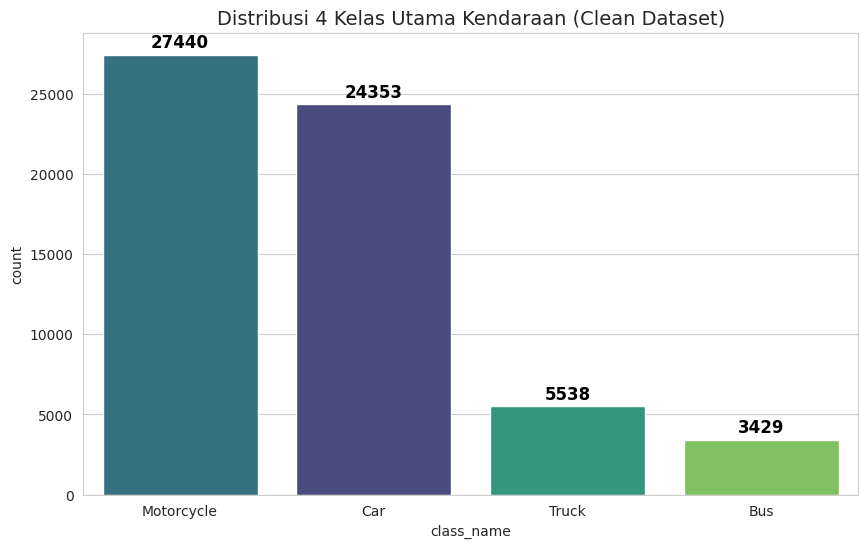


📊 TABEL RINGKASAN DATASET


,Jumlah,Persentase
class_name,,
Motorcycle,27440,45.16%
Car,24353,40.08%
Truck,5538,9.11%
Bus,3429,5.64%


Total Objek Terdeteksi: 60760 label


In [ ]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# --- 1. DEFINISIKAN LOKASI LANGSUNG DI SINI ---
# Pastikan nama folder ini sesuai dengan yang ada di sidebar kiri Colab kamu
dataset_location = "/content/Traffic-Detection-Capstone-FINAL-1"

def run_final_eda():
    # Cek apakah folder dataset ada
    if not os.path.exists(dataset_location):
        print(f"❌ Error: Folder '{dataset_location}' tidak ditemukan!")
        print("Pastikan kamu sudah menjalankan sel Download Dataset di Step 2.")
        return

    labels = []
    # Mencari file .txt di folder train/labels
    path = os.path.join(dataset_location, 'train/labels/*.txt')
    files = glob.glob(path)

    for file in files:
        with open(file, 'r') as f:
            for line in f:
                parts = line.split()
                if len(parts) > 0:
                    labels.append(int(parts[0]))

    if len(labels) == 0:
        print("❌ Error: Tidak ada data label (file .txt kosong).")
        print("Pastikan kamu sudah menjalankan sel Cleaning di Step 3.")
        return

    # Buat DataFrame
    df = pd.DataFrame(labels, columns=['id'])

    # 2. Mapping ID sesuai hasil Cleaning Hasna (4 Kelas)
    id_to_name = {0:'Motorcycle', 1:'Car', 2:'Bus', 3:'Truck'}
    df['class_name'] = df['id'].map(id_to_name)

    # --- GRAFIK ---
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    # Menampilkan grafik dengan hue untuk menghindari warning terbaru
    order_list = ['Motorcycle', 'Car', 'Truck', 'Bus']
    ax = sns.countplot(data=df, x='class_name', hue='class_name',
                       palette='viridis', order=order_list, legend=False)

    # Menambahkan angka jumlah di atas setiap batang grafik
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='baseline', fontsize=12,
                        color='black', weight='bold', xytext=(0, 5),
                        textcoords='offset points')

    plt.title('Distribusi 4 Kelas Utama Kendaraan (Clean Dataset)', fontsize=14)
    plt.show()

    # --- TABEL STATISTIK ---
    print("\n" + "="*35)
    print("📊 TABEL RINGKASAN DATASET")
    print("="*35)

    counts = df['class_name'].value_counts()
    percent = df['class_name'].value_counts(normalize=True) * 100

    summary_df = pd.DataFrame({
        'Jumlah': counts,
        'Persentase': percent.map('{:.2f}%'.format)
    })

    display(summary_df)
    print(f"Total Objek Terdeteksi: {len(df)} label")
    print("="*35)

# JALANKAN PROGRAMNYA
run_final_eda()

### **💡 Hasil Analisis & Insight (Data Scientist Report - FINAL)**

Berdasarkan hasil visualisasi data terbaru setelah finalisasi proses *cleaning* pada proyek **Traffic-Detection-Capstone-Final**, berikut adalah temuan tim Data Scientist:

#### **1. Dominansi Kendaraan (Menjawab Q1)**
Dataset didominasi oleh **Motorcycle (45.16%)** dan **Car (40.08%)**.
*   **Insight:** Komposisi ini mencerminkan realitas lalu lintas heterogen di Indonesia dengan sangat akurat. Dengan total gabungan lebih dari **51.700 label** untuk kendaraan pribadi, model AI akan memiliki basis pengetahuan yang sangat luas untuk mendeteksi arus utama lalu lintas di area perkotaan.

#### **2. Validasi Keseimbangan Data (Menjawab Q2)**
Dataset dinyatakan dalam kondisi **Sangat Seimbang (Well-Balanced)** untuk kelas-kelas mayoritas.
*   **Insight:** Selisih antara populasi Motor dan Mobil sangat tipis, hanya berkisar **5.08%**. Keseimbangan ini sangat krusial untuk memastikan model YOLOv8 tidak bias, sehingga akurasi deteksi antara motor dan mobil di lapangan akan setara, adil, dan konsisten.

#### **3. Rasio Kendaraan Berat (Menjawab Q3)**
Ditemukan bahwa untuk setiap **1 unit mobil** di dalam dataset, terdapat sekitar **0.37 unit kendaraan berat** (gabungan Bus & Truk).
*   **Insight:** Meskipun kelas **Bus (5.64%)** memiliki persentase terkecil, namun secara jumlah absolut kita memiliki **3.429 data**. Angka ini sudah jauh melampaui ambang batas aman training Deep Learning (minimum 2.000 objek), sehingga AI dipastikan mampu mengenali bus dan truk dengan performa tinggi.

---
**Kesimpulan Strategis:** Dengan total **60.760 label** kendaraan yang telah diverifikasi dan dibersihkan dari *redundancy* nama, dataset dinyatakan **VALID** dan **SIAP 100%** untuk dilanjutkan ke proses training model YOLOv8 oleh tim AI Engineer

# **V. Data Dictionary & Standar Klasifikasi** 📖

Dokumentasi ini adalah panduan klasifikasi final yang digunakan oleh tim **TrafficSense AI**. Kami menyederhanakan **43 kelas asli** menjadi **4 Kelas Utama** demi meningkatkan akurasi deteksi dan kemudahan analisis volume jalan.

### **Apa itu 'smp' (Satuan Mobil Penumpang)?**
Dalam teknik sipil, kemacetan tidak dihitung hanya dari jumlah unit. **1 Bus besar** memakan ruang jalan lebih banyak dan bergerak lebih lambat daripada **1 Mobil pribadi**. Oleh karena itu, kita memberikan "bobot" dampak kemacetan yang disebut **smp** (merujuk pada **PKJI 2023**).

| ID | Nama Kelas | Deskripsi Kendaraan | Standar PKJI 2023 | Bobot (smp) | Penjelasan untuk Orang Awam |
| :---: | :--- | :--- | :---: | :---: | :--- |
| **0** | **Motorcycle** | Motor roda 2, roda 3, sepeda. | **SM** | **0.50** | 2 Motor dianggap memakan tempat 1 Mobil standar. |
| **1** | **Car** | Mobil, **Angkot**, **Pickup**, Van, Ambulance. | **MP** | **1.00** | Dijadikan standar dasar perhitungan ruang jalan. |
| **2** | **Bus** | Bus sedang, bus besar, pariwisata. | **KS** | **1.30** | 1 Bus memakan 1,3x ruang jalan Mobil biasa. |
| **3** | **Truck** | Truk logistik, engkel, box, gandar. | **KS** | **1.30** | 1 Truk memakan 1,3x ruang jalan Mobil biasa. |

### **Catatan Teknis Pembersihan Data:**
1.  **Merging Strategis:** Kami menggabungkan kelas **Angkot** dan **Pickup** ke dalam kategori **Car** karena jumlah datanya yang sedikit (minoritas). Tindakan ini mencegah model AI menjadi bingung dan meningkatkan akurasi deteksi kendaraan roda 4 secara keseluruhan.
2.  **Analisis Kepadatan:** Meskipun model AI mendeteksi 4 jenis kendaraan, sistem perhitungan kemacetan pada dashboard nantinya akan tetap merujuk pada 3 kategori utama PKJI (**SM, MP, KS**) dengan menjumlahkan output Bus dan Truck.

# **6. Custom Model Training (Tugas Nabilla & Firaz)** 🤖
---
⚠️ **INSTRUKSI UNTUK AI ENGINEER:**  
Harap jalankan Step 1 sampai Step 3 terlebih dahulu secara berurutan agar ID kelas di folder labels ter-remapping otomatis sebelum memulai training di bawah ini.  
**Dataset Configuration:** `/content/Traffic-Detection-Capstone-1/data.yaml`
---

## Custom Training

In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=25 imgsz=800 plots=True

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate Custom Model

In [ ]:
%cd {HOME}

!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

## Inference with Custom Model

In [ ]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

**NOTE:** Let's take a look at few results.

In [ ]:
import glob
from IPython.display import Image, display

# Define the base path where the folders are located
base_path = '/content/runs/detect/'

# List all directories that start with 'predict' in the base path
subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict')]

# Find the latest folder by modification time
latest_folder = max(subfolders, key=os.path.getmtime)

image_paths = glob.glob(f'{latest_folder}/*.jpg')[:3]

# Display each image
for image_path in image_paths:
    display(Image(filename=image_path, width=600))
    print("\n")

## Deploy model on Roboflow

Once you have finished training your YOLOv8 model, you’ll have a set of trained weights ready for use. These weights will be in the `/runs/detect/train/weights/best.pt` folder of your project. You can upload your model weights to Roboflow Deploy to use your trained weights on our infinitely scalable infrastructure.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) now supports uploading YOLOv8 weights.

To upload model weights, add the following code to the “Inference with Custom Model” section in the aforementioned notebook:

In [ ]:
project.version(dataset.version).deploy(model_type="yolov8", model_path=f"{HOME}/runs/detect/train/")

Follow the links above to check if the upload succeeded. It may take a couple of minutes until the model is visible to the `roboflow` SDK.

In [ ]:
# Run inference on your model on a persistent, auto-scaling, cloud API

# Load model
model = project.version(dataset.version).model
assert model, "Model deployment is still loading"

# Choose a random test image
import os, random
test_set_loc = dataset.location + "/test/images/"
random_test_image = random.choice(os.listdir(test_set_loc))
print("running inference on " + random_test_image)

pred = model.predict(test_set_loc + random_test_image, confidence=40, overlap=30).json()
pred

# Deploy Your Model to the Edge

In addition to using the Roboflow hosted API for deployment, you can use [Roboflow Inference](https://inference.roboflow.com), an open source inference solution that has powered millions of API calls in production environments. Inference works with CPU and GPU, giving you immediate access to a range of devices, from the NVIDIA Jetson to TRT-compatible devices to ARM CPU devices.

With Roboflow Inference, you can self-host and deploy your model on-device. You can deploy applications using the [Inference Docker containers](https://inference.roboflow.com/quickstart/docker/) or the pip package.

For example, to install Inference on a device with an NVIDIA GPU, we can use:

```
docker pull roboflow/roboflow-inference-server-gpu
```

Then we can run inference via HTTP:

```python
import requests

workspace_id = ""
model_id = ""
image_url = ""
confidence = 0.75
api_key = ""

infer_payload = {
    "image": {
        "type": "url",
        "value": image_url,
    },
    "confidence": confidence,
    "iou_threshold": iou_thresh,
    "api_key": api_key,
}
res = requests.post(
    f"http://localhost:9001/{workspace_id}/{model_id}",
    json=infer_object_detection_payload,
)

predictions = res.json()
```

Above, set your Roboflow workspace ID, model ID, and API key.

- [Find your workspace and model ID](https://docs.roboflow.com/api-reference/workspace-and-project-ids?ref=blog.roboflow.com)
- [Find your API key](https://docs.roboflow.com/api-reference/authentication?ref=blog.roboflow.com#retrieve-an-api-key)

Also, set the URL of an image on which you want to run inference. This can be a local file.

_To use your YOLOv5 model commercially with Inference, you will need a Roboflow Enterprise license, through which you gain a pass-through license for using YOLOv5. An enterprise license also grants you access to features like advanced device management, multi-model containers, auto-batch inference, and more._